IMOPRTION & LOADING OF DATA

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Load your specific file
df = pd.read_excel('/content/drive/MyDrive/PROJECT/dataset.xlsx')

# 3. Quick Data Cleaning (based on your file structure)
# Your dataset includes columns like 'Airline', 'Source', 'Economy', 'Price', etc.
# Note: You may need to rename columns if they have spaces or different headers.

# Example: If the last column is the price
# X = df.iloc[:, :-1]
# y = df.iloc[:, -1]

print("Dataset loaded successfully!")

# Load your dataset
# df = pd.read_csv('flight_data.csv')

# For demonstration, let's assume a structure:
# Features: Airline, Source, Destination, Date_of_Journey, Dep_Time, Duration, Total_Stops
# Target: Price

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!


FEATURE ENGINEERING



In [ ]:
def clean_flight_data(df):
    df_cleaned = df.copy()

    # Drop the 'Unnamed: 0' column if it exists, as it's likely an artifact.
    if 'Unnamed: 0' in df_cleaned.columns:
        df_cleaned.drop('Unnamed: 0', axis=1, inplace=True)

    # 1. Handle 'stops' (Ordinal Mapping)
    # The column is 'stops' in the raw df.
    # The values are 'Non-stop', '1-stop', '2+-stop'. Map '2+-stop' to 2 stops.
    stop_map = {"Non-stop": 0, "1-stop": 1, "2+-stop": 2}
    df_cleaned["Total_Stops"] = df_cleaned["stops"].map(stop_map)
    df_cleaned.drop("stops", axis=1, inplace=True) # Drop original 'stops' column

    # 2. 'duration' column is not present in the dataset.
    # The code to process 'duration' has been removed.

    # 3. One-Hot Encoding for Categorical Data
    # Columns to encode: 'airline', 'source_city', 'destination_city', 'departure_time', 'class', 'arrival_time'
    categorical_cols = ["airline", "source_city", "destination_city", "departure_time", "class", "arrival_time"]
    df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

    # 'days_left' is mentioned in the original problem statement but is not present in the current dataframe.
    # So no action is taken regarding 'days_left'.

    return df_cleaned

df_final = clean_flight_data(df)

MODELTRAIN & PRED

In [ ]:
# Split features and target
X = df_final.drop("price", axis=1)
y = df_final["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Model
regressor = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

# Fit Model
regressor.fit(X_train, y_train)

# Predict
y_pred = regressor.predict(X_test)

EVALUATION

R2 Score: 0.9537
MAE: 3161.26
RMSE: 4889.32


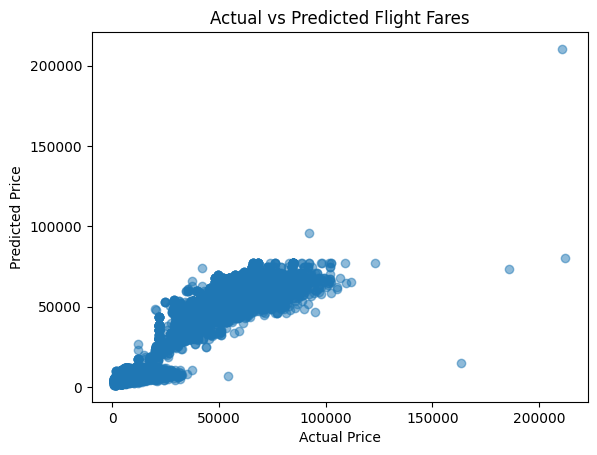

In [ ]:
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Visualize actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Fares")
plt.show()

In [16]:
import joblib

# 1. Save the trained model
joblib.dump(regressor, 'flight_model.pkl')

# 2. Save the column names (Crucial for One-Hot Encoding consistency)
model_columns = list(X_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Model and Columns saved successfully!")

Model and Columns saved successfully!
